In [1]:
import pandas as pd
import networkx as nx
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load data
df = pd.read_csv('multi_platform_social_sentiment_evolution.csv')

# 2. Xây dựng đồ thị (Graph Construction)
G = nx.Graph()

# Tạo danh sách các nhóm dựa trên location, sentiment và hour
# Nhóm theo: [location, sentiment_category, hour_of_day]
groups = df.groupby(['location', 'sentiment_category', 'hour_of_day'])

for name, group in groups:
    topics = group['topic'].unique()
    if len(topics) > 1:
        # Tạo cạnh giữa tất cả các cặp topic xuất hiện cùng nhau trong nhóm này
        from itertools import combinations
        for t1, t2 in combinations(topics, 2):
            if G.has_edge(t1, t2):
                G[t1][t2]['weight'] += 1
            else:
                G.add_edge(t1, t2, weight=1)

# 3. Trích xuất đặc trưng (Feature Extraction)
# Tính PageRank cho mỗi Topic
pagerank_scores = nx.pagerank(G, weight='weight')

# Ánh xạ PageRank score ngược lại vào dataframe chính
df['topic_pagerank'] = df['topic'].map(pagerank_scores).fillna(0)

print(f"Hoàn thành tính PageRank. Top 5 Topic quan trọng: {sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:5]}")

Hoàn thành tính PageRank. Top 5 Topic quan trọng: [('Food', 0.06732512188430068), ('Finance', 0.0672126928919192), ('Education', 0.06721266225185912), ('Science', 0.06720139917570186), ('Climate', 0.06697661534968102)]


In [2]:
# 1. Xuất file Nodes
nodes_data = []
for node in G.nodes():
    nodes_data.append({
        'Id': node,
        'Label': node,
        'PageRank': pagerank_scores.get(node, 0)
    })
pd.DataFrame(nodes_data).to_csv('nodes.csv', index=False)

# 2. Xuất file Edges
edges_data = []
for u, v, data in G.edges(data=True):
    edges_data.append({
        'Source': u,
        'Target': v,
        'Weight': data['weight']
    })
pd.DataFrame(edges_data).to_csv('edges.csv', index=False)

print("Đã xuất xong nodes.csv và edges.csv. Hãy mở Gephi và Import Spreadsheet!")

Đã xuất xong nodes.csv và edges.csv. Hãy mở Gephi và Import Spreadsheet!


In [ ]:
import pandas as pd
import networkx as nx

# Chuyển cột date sang định dạng datetime
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

dynamic_features = []

# Duyệt qua từng tháng để xây dựng đồ thị riêng cho tháng đó
for month in df['month'].unique():
    month_df = df[df['month'] == month]
    
    # Tạo đồ thị giống như bước trước bạn đã làm
    G_month = nx.Graph()
    groups = month_df.groupby(['location', 'sentiment_category', 'hour_of_day'])
    
    for _, group in groups:
        topics = group['topic'].unique()
        if len(topics) > 1:
            from itertools import combinations
            for t1, t2 in combinations(topics, 2):
                if G_month.has_edge(t1, t2):
                    G_month[t1][t2]['weight'] += 1
                else:
                    G_month.add_edge(t1, t2, weight=1)
    
    # Tính PageRank của tháng này
    pagerank_month = nx.pagerank(G_month, weight='weight')
    
    # Lưu kết quả
    for topic, score in pagerank_month.items():
        dynamic_features.append({
            'month': month,
            'topic': topic,
            'dynamic_pagerank': score
        })
# Tạo DataFrame đặc trưng động
df_dynamic = pd.DataFrame(dynamic_features)
# Merge ngược lại vào dataset chính
df = pd.merge(df, df_dynamic, on=['month', 'topic'], how='left').fillna(0)

print(df[['date', 'topic', 'dynamic_pagerank']].head())

        date      topic  dynamic_pagerank
0 2025-04-19    Finance          0.065308
1 2025-04-19       Food          0.069020
2 2025-04-19     Sports          0.067248
3 2025-04-19  Education          0.067818
4 2025-04-19     Gaming          0.066021


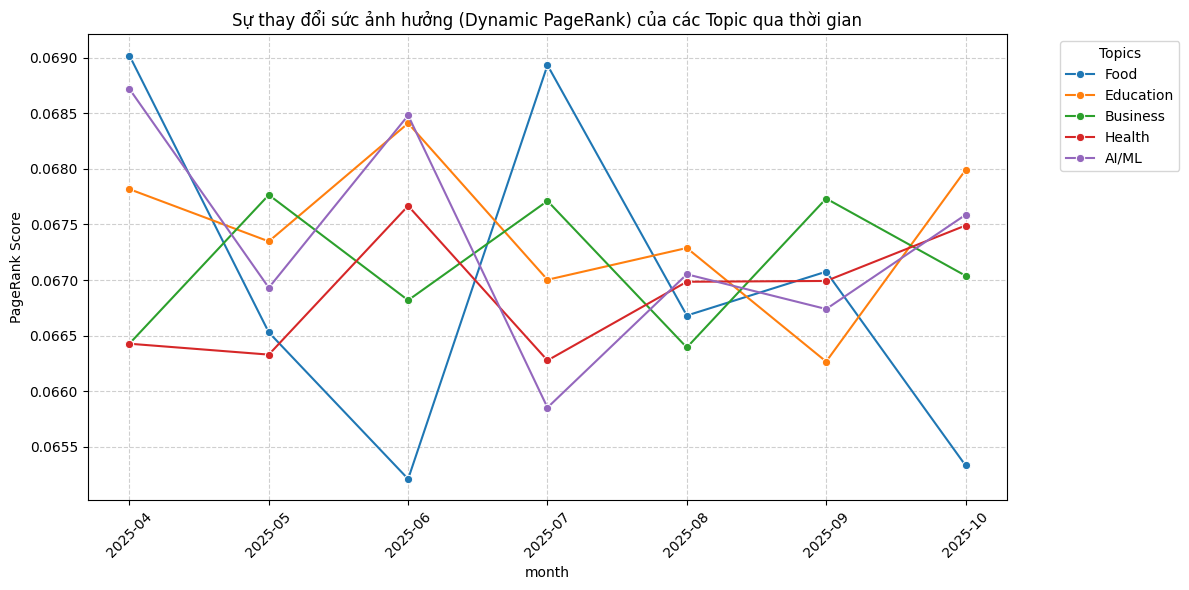

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chuẩn bị dữ liệu: Lấy Top 5 topic có trung bình PageRank cao nhất để vẽ cho đỡ rối
top_topics = df.groupby('topic')['dynamic_pagerank'].mean().nlargest(5).index
plot_df = df[df['topic'].isin(top_topics)].drop_duplicates(['month', 'topic']).sort_values('month')

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x=plot_df['month'].astype(str), y='dynamic_pagerank', hue='topic', marker='o')
plt.title('Sự thay đổi sức ảnh hưởng (Dynamic PageRank) của các Topic qua thời gian')
plt.xticks(rotation=45)
plt.ylabel('PageRank Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Topics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
# --- STEP 1: LOAD DỮ LIỆU ---
df_main = pd.read_csv('multi_platform_social_sentiment_evolution.csv')
df_gephi = pd.read_csv('gephi-result-1.csv')

# Đồng bộ thời gian
df_main['date'] = pd.to_datetime(df_main['date'])
df_main['month'] = df_main['date'].dt.to_period('M')

In [7]:
# --- STEP 2: TÍCH HỢP FEATURE TỪ GEPHI (LỌC FEATURE QUAN TRỌNG) ---
# Thay thế betweenness (bằng 0) bằng Authority và Hub có giá trị hơn
gephi_features = ['Id', 'pagerank', 'Authority', 'Hub', 'closnesscentrality', 'modularity_class']
df_gephi_selected = df_gephi[gephi_features].rename(columns={'Id': 'topic'})

# Merge dữ liệu mạng lưới tĩnh
df_final = pd.merge(df_main, df_gephi_selected, on='topic', how='left')

# Giả sử bạn đã có DataFrame df_dynamic chứa kết quả Dynamic PageRank từ bước trước
# Nếu chưa có, hãy đảm bảo biến df_dynamic tồn tại trong môi trường code
df_final = pd.merge(df_final, df_dynamic[['month', 'topic', 'dynamic_pagerank']], 
                     on=['month', 'topic'], how='left')

In [8]:
# --- STEP 3: TẠO ĐỘ TRỄ (LAG) & MÂM CƠM TREND ---
df_final = df_final.sort_values(['topic', 'date'])

# Fill dynamic_pagerank bằng pagerank tĩnh nếu tháng đó topic chưa có chỉ số riêng
df_final['dynamic_pagerank'] = df_final['dynamic_pagerank'].fillna(df_final['pagerank'])

# Tạo PageRank của tháng trước (Lag Feature)
df_final['pagerank_last_month'] = df_final.groupby('topic')['dynamic_pagerank'].shift(1).fillna(df_final['pagerank'])

# Tính toán Trend (Xu hướng) và Momentum (Đà tăng trưởng)
df_final['pagerank_trend'] = df_final['dynamic_pagerank'] - df_final['pagerank_last_month']
df_final['pagerank_momentum'] = df_final['dynamic_pagerank'] - df_final['pagerank']

In [9]:
# --- STEP 4: PRE-PROCESSING (SỐ HÓA DỮ LIỆU) ---
df_final['sentiment_numeric'] = df_final['sentiment_category'].astype('category').cat.codes
df_final['media_numeric'] = df_final['media_type'].astype('category').cat.codes
df_final['platform_numeric'] = df_final['platform'].astype('category').cat.codes
df_final['location_numeric'] = df_final['location'].astype('category').cat.codes

In [10]:
# --- STEP 5: HUẤN LUYỆN MODEL XGBOOST ---
# Tập hợp Features bao gồm cả Tĩnh, Động và Nội dung
features = [
    'followers', 'hour_of_day', 'day_of_week', 'is_weekend', 'content_length', 
    'num_hashtags', 'sentiment_positive', 'sentiment_negative',
    'pagerank', 'Authority', 'Hub', 'closnesscentrality', 'modularity_class', # Gephi Static (đã lọc)
    'dynamic_pagerank', 'pagerank_last_month', 'pagerank_trend', 'pagerank_momentum', # Network Dynamic
    'sentiment_numeric', 'media_numeric', 'platform_numeric', 'location_numeric'
]

In [13]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
X = df_final[features]
y = df_final['total_engagement']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Khởi tạo XGBoost với tham số tối ưu hơn cho dữ liệu phức tạp
xgb_model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.03, # Giảm tốc độ học để model bền bỉ hơn
    max_depth=7, 
    subsample=0.8, 
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


--- KẾT QUẢ BASELINE (XGBOOST + ENHANCED NETWORK FEATURES) ---
MAE: 497.31
RMSE: 2524.61
R2 Score: 0.3898


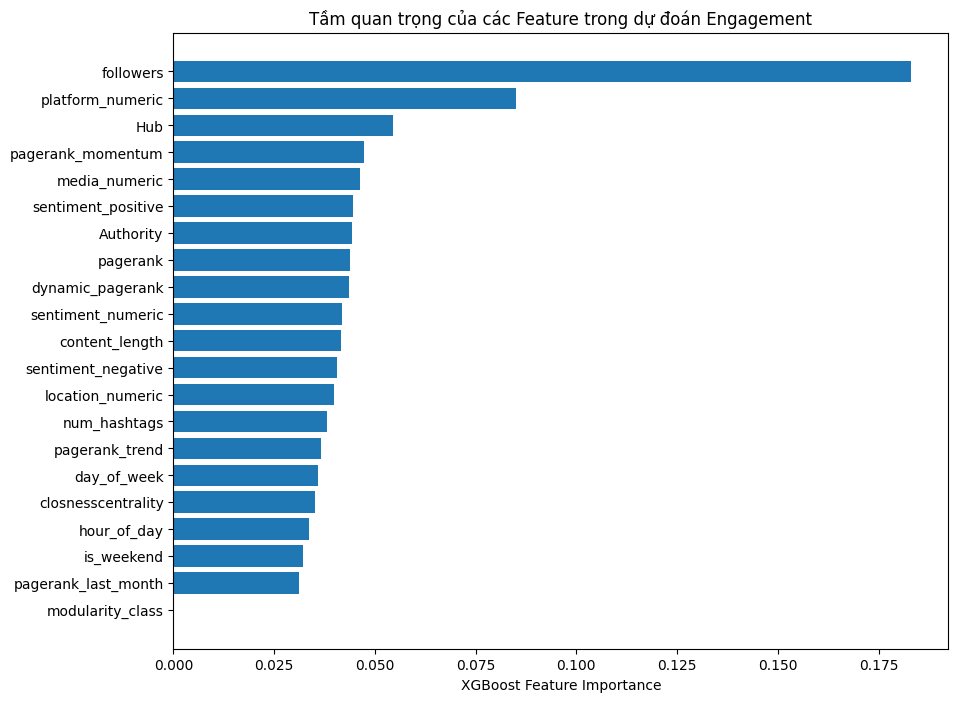

In [14]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
# --- STEP 6: ĐÁNH GIÁ VÀ TRỰC QUAN HÓA ĐỘ QUAN TRỌNG ---
y_pred = xgb_model.predict(X_test)

print(f"--- KẾT QUẢ BASELINE (XGBOOST + ENHANCED NETWORK FEATURES) ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# Vẽ Feature Importance để xem PageRank "đáng giá" thế nào
plt.figure(figsize=(10, 8))
sorted_idx = xgb_model.feature_importances_.argsort()
plt.barh(np.array(features)[sorted_idx], xgb_model.feature_importances_[sorted_idx])
plt.xlabel("XGBoost Feature Importance")
plt.title("Tầm quan trọng của các Feature trong dự đoán Engagement")
plt.show()

GCN

In [16]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

# 1. Định nghĩa danh sách Topic và tạo ID
topics = df_final['topic'].unique()
topic_to_idx = {t: i for i, t in enumerate(topics)}
num_topics = len(topics)

# 2. Tạo Edge Index (Dựa trên đồ thị bạn đã làm ở Gephi/NetworkX)
# Lấy các cạnh từ đồ thị G mà bạn đã xây dựng ở bước đầu
edge_list = []
for u, v in G.edges():
    edge_list.append([topic_to_idx[u], topic_to_idx[v]])
    edge_list.append([topic_to_idx[v], topic_to_idx[u]]) # Đồ thị vô hướng
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# 3. Tạo Node Features (X)
# Mỗi topic sẽ được đại diện bằng giá trị trung bình của các đặc trưng trong dataset
node_feats = []
for t in topics:
    # Lấy trung bình các chỉ số của topic đó để làm đặc trưng ban đầu cho Node
    feat = df_final[df_final['topic'] == t][['sentiment_positive', 'sentiment_negative', 'followers']].mean().values
    node_feats.append(feat)
x = torch.tensor(node_feats, dtype=torch.float)

C:\Users\khoav\AppData\Local\Temp\ipykernel_29124\1554553192.py:26: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  x = torch.tensor(node_feats, dtype=torch.float)


In [70]:
class PopularityGCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(PopularityGCN, self).__init__()
        # Lớp GCN thứ nhất
        self.conv1 = GCNConv(input_dim, hidden_dim)
        # Lớp GCN thứ hai (để lấy Embedding cuối cùng)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # Lan truyền qua lớp 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        # Lan truyền qua lớp 2 để lấy Embedding 16 chiều
        x = self.conv2(x, edge_index)
        
        return x

# Khởi tạo model (Ví dụ: input=3, hidden=16, output=16)
model_gcn = PopularityGCN(input_dim=x.shape[1], hidden_dim=32, output_dim=16)
data_gcn = Data(x=x, edge_index=edge_index)

In [71]:
# Lấy Embeddings từ GCN (trước khi train hoặc sau khi train nhẹ)
model_gcn.eval()
with torch.no_grad():
    topic_embeddings = model_gcn(data_gcn).numpy()

# Chuyển Embeddings thành DataFrame để merge vào Dataset chính
embedding_cols = [f'gcn_emb_{i}' for i in range(16)]
df_emb = pd.DataFrame(topic_embeddings, index=topics, columns=embedding_cols).reset_index()
df_emb = df_emb.rename(columns={'index': 'topic'})

# Merge vào dataset cũ của bạn
df_gcn_final = pd.merge(df_final, df_emb, on='topic', how='left')

In [73]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Lấy danh sách feature (cũ + 16 cột GCN)
gcn_features = [f'gcn_emb_{i}' for i in range(16)]
final_features_list = features + gcn_features 

X = df_gcn_final[final_features_list]
y_raw = df_gcn_final['total_engagement']

# 2. Chia tập dữ liệu TRƯỚC khi biến đổi để tránh leakage (đúng ý thầy)
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y_raw, test_size=0.1, random_state=42)

# 3. Biến đổi Log cho tập Train và Test
y_train_log = np.log1p(y_train_raw)
y_test_log = np.log1p(y_test_raw)

In [63]:
# Huấn luyện mô hình với y đã Log
xgb_final = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_final.fit(X_train, y_train_log)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [67]:
# 1. Dự đoán (kết quả đang ở dạng Log)
y_pred_log = xgb_final.predict(X_test)

# 2. Tránh giá trị âm (log của giá trị >=0 nên clip về 0 nếu model dự đoán âm)
y_pred_log_clipped = np.clip(y_pred_log, a_min=0.0, a_max=None)

# 3. Đưa về đơn vị gốc (Engagement)
y_pred_final = np.expm1(y_pred_log_clipped)

# 4. Tính toán các chỉ số
r2_log = r2_score(y_test_log, y_pred_log_clipped)
mae_orig = mean_absolute_error(y_test_raw, y_pred_final)

print("--- KẾT QUẢ THỰC NGHIỆM CHUẨN ---")
print(f"1. R2 Score (Log Scale): {r2_log:.4f}")
print(f"2. MAE (Lượt tương tác): {mae_orig:.2f}")

--- KẾT QUẢ THỰC NGHIỆM CHUẨN ---
1. R2 Score (Log Scale): 0.5877
2. MAE (Lượt tương tác): 377.40


In [56]:
from lightgbm import LGBMRegressor

# Train thêm LightGBM để so sánh
lgbm_model = LGBMRegressor(n_estimators=1000, learning_rate=0.02, max_depth=8, random_state=42)
lgbm_model.fit(X_train, y_train_log)

y_pred_lgbm = lgbm_model.predict(X_test)
r2_lgbm = r2_score(y_test_log, y_pred_lgbm)

print(f"R2 Score của LightGBM: {r2_lgbm:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1509
[LightGBM] [Info] Number of data points in the train set: 135000, number of used features: 28
[LightGBM] [Info] Start training from score 2.211991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
R2 Score của LightGBM: 0.5929


In [74]:
from sklearn.ensemble import RandomForestRegressor

# 1. Khởi tạo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# 2. Huấn luyện (Dùng cùng bộ dữ liệu X_train, y_train_log như XGBoost)
rf_model.fit(X_train, y_train_log)

# 3. Dự đoán và tính R2
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test_log, y_pred_rf)

print(f"MAE của Random Forest + GCN: {mean_absolute_error(y_test_log, y_pred_rf):.4f}")
print(f"R2 Score của Random Forest + GCN: {r2_rf:.4f}")

MAE của Random Forest + GCN: 1.1389
R2 Score của Random Forest + GCN: 0.5935


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# 1. Khởi tạo Scaler cho X (Cực kỳ quan trọng cho NN)
scaler_x = StandardScaler()

# 2. Fit và Transform tập train, chỉ Transform tập test (Tránh Leakage)
X_train_g_scaled = scaler_x.fit_transform(X_train_g)
X_test_g_scaled = scaler_x.transform(X_test_g)

# 3. Chạy lại Neural Network với dữ liệu đã chuẩn hóa
nn_final = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000, # Tăng số vòng lặp để hội tụ
    early_stopping=True, # Tự dừng khi không cải thiện để tránh overfitting
    random_state=42
)

nn_final.fit(X_train_g_scaled, y_train_log)

# 4. Dự đoán
y_pred_nn_g = nn_final.predict(X_test_g_scaled)
r2_nn_g = r2_score(y_test_log, y_pred_nn_g)

print(f"--- KẾT QUẢ NN SAU KHI SCALE X ---")
print(f"R2 Score của Neural Network + GCN: {r2_nn_g:.4f}")

--- KẾT QUẢ NN SAU KHI SCALE X ---
R2 Score của Neural Network + GCN: 0.5328


In [75]:
print(f"MAE của Neural Network + GCN: {mean_absolute_error(y_test_log, y_pred_nn_g):.4f}")

MAE của Neural Network + GCN: 1.3013


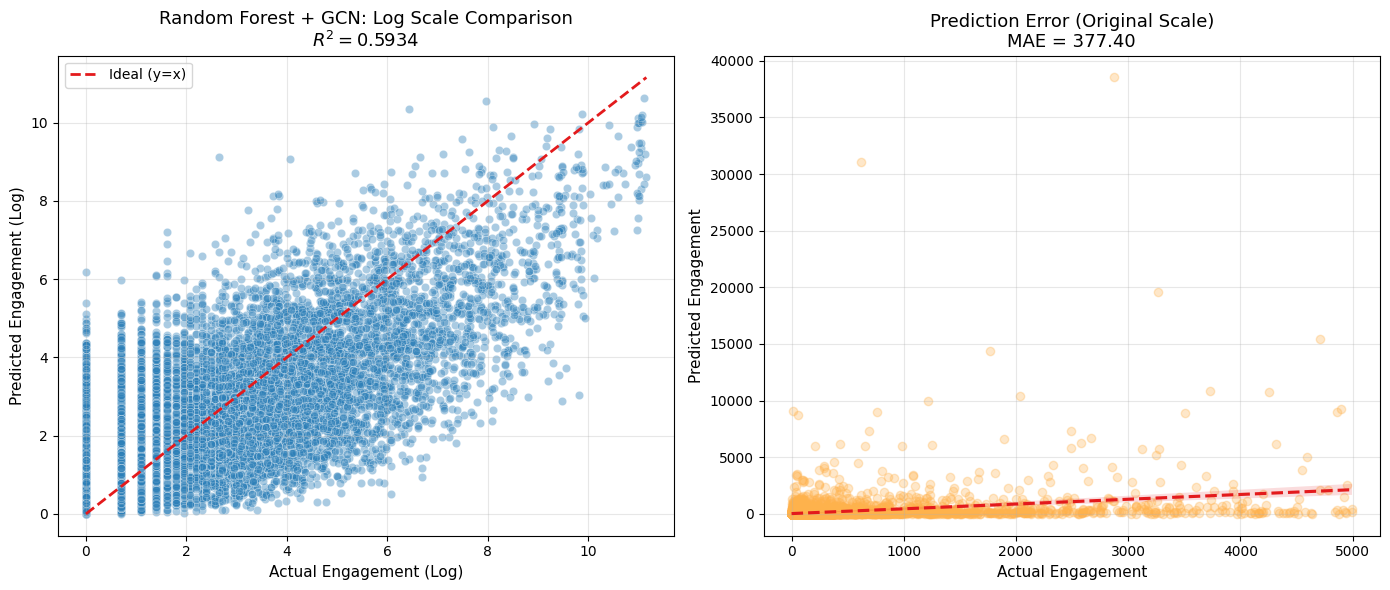

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sử dụng kết quả từ Random Forest (y_pred_rf là dự đoán trên thang Log)
# 1. Đưa về đơn vị gốc để tính MAE thực tế cho biểu đồ
y_pred_rf_orig = np.expm1(y_pred_rf) 

plt.figure(figsize=(14, 6))

# --- BIỂU ĐỒ 1: THANG LOG (Chứng minh độ tương quan) ---
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_log, y=y_pred_rf, alpha=0.4, color='#2c7fb8')
line = np.linspace(y_test_log.min(), y_test_log.max(), 100)
plt.plot(line, line, color='#e31a1c', linestyle='--', linewidth=2, label='Ideal (y=x)')
plt.title(f'Random Forest + GCN: Log Scale Comparison\n$R^2 = 0.5934$', fontsize=13)
plt.xlabel('Actual Engagement (Log)', fontsize=11)
plt.ylabel('Predicted Engagement (Log)', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

# --- BIỂU ĐỒ 2: SAI SỐ TUYỆT ĐỐI (Dưới 5000 tương tác) ---
plt.subplot(1, 2, 2)
# Lọc để nhìn rõ dải dữ liệu phổ biến nhất
mask = y_test_raw < 5000
sns.regplot(x=y_test_raw[mask], y=y_pred_rf_orig[mask], 
            scatter_kws={'alpha':0.3, 'color':'#feb24c'}, 
            line_kws={'color':'#e31a1c', 'linestyle':'--'})
plt.title(f'Prediction Error (Original Scale)\nMAE = 377.40', fontsize=13)
plt.xlabel('Actual Engagement', fontsize=11)
plt.ylabel('Predicted Engagement', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()